# Анализ Кадров



Для анализа кадров воспользуемся данными с rosstat.ru и hh.ru. Нас будут интересовать данные именно по профессиям в сфере IT.

### Список задач

1. Анализ кадров через сайт rosstat.ru
    - Статистический парсер для rosstat.ru
    - Анализ данных по издержкам
    - Анализ данных по рабочей силе
2. Анализ кадров через сайт hh.ru
    - Динамический парсер для hh.ru
3. Графики 
4. Дашборд

In [1]:
import requests
import pandas as pd
import re
import io
import asyncio
import urllib3
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from bs4 import BeautifulSoup
from playwright.async_api import async_playwright
from dash import Dash, dcc, html
import plotly.express as px
import plotly.graph_objects as go

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

## Анализ кадров через сайт rosstat.ru

### Статистический парсер для rosstat.ru

In [2]:
class RosstatParser:
    BASE_URL = "https://rosstat.gov.ru"

    def __init__(self):
        self.session = requests.Session()
        self.session.headers.update({
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
        })

    def get_page(self, url: str) -> BeautifulSoup:
        response = self.session.get(url, timeout=10, verify=False)
        response.raise_for_status()
        return BeautifulSoup(response.text, "lxml")


    def find_excel_links(self, page_url: str) -> list[dict]:
        soup = self.get_page(page_url)
        links = []
        for tag in soup.find_all("a", href=True):
            href = tag["href"]
            if href.endswith((".xlsx", ".xls")):
                full_url = self.BASE_URL + href if href.startswith("/") else href
                links.append({
                    "name": tag.get_text(strip=True),
                    "url": full_url
                })
        return links

    def download_excel(self, url: str) -> pd.DataFrame:
        response = self.session.get(url, timeout=15, verify = False)
        response.raise_for_status()
        return pd.read_excel(io.BytesIO(response.content), header=None)

    def parse_labour_costs(self) -> list[dict]:
        url = f"{self.BASE_URL}/labour_costs"
        print(f"Ищем Excel-файлы на: {url}")
        links = self.find_excel_links(url)
        print(f"Найдено файлов: {len(links)}")
        for link in links:
            print(f"  - {link['name']}: {link['url']}")
        return links

parser = RosstatParser()
links_force = parser.find_excel_links("https://rosstat.gov.ru/labour_force")
links_costs = parser.find_excel_links("https://rosstat.gov.ru/labour_costs")

### Анализ данных по издержкам

In [3]:
df_edu = parser.download_excel(links_costs[7]["url"])
edu_clean = df_edu.iloc[4:10, :].copy()
years_edu = [str(int(float(c))) if str(c) not in ["20251)", "nan"] else "2025" for c in df_edu.iloc[3, 1:].values]
edu_clean.columns = ["категория"] + years_edu
edu_clean["категория"] = [
    "Все работники",
    "Высшее профессиональное",
    "Среднее профессиональное",
    "Среднее общее",
    "Основное общее",
    "Не имеют основного общего"
]

edu_clean = edu_clean[(edu_clean["категория"] == "Высшее профессиональное")|
                      (edu_clean["категория"] == "Среднее профессиональное")|
                      (edu_clean["категория"] == "Среднее общее")]

edu_clean = edu_clean.set_index("категория")
edu_clean = edu_clean.apply(pd.to_numeric, errors="coerce")
print("Зарплаты по уровню образования:")
print(edu_clean)

df_med = parser.download_excel(links_costs[10]["url"])
med_clean = df_med.iloc[4, 1:].copy()
years_med = [str(c).replace(" 2", "").strip() for c in df_med.iloc[3, 1:].values]
med_clean.index = years_med
med_clean = pd.to_numeric(med_clean, errors="coerce")
med_clean.name = "медианная_зарплата"
print("\nМедианная зарплата по годам:")
print(med_clean)

Зарплаты по уровню образования:
                              2005     2007     2009     2011     2013  \
категория                                                                
Высшее профессиональное   11383.15  17799.0  24366.0  29927.0  38233.0   
Среднее профессиональное   7722.18  11830.0  15276.0  18901.0  23869.0   
Среднее общее              7726.29  11787.0  14780.0  18538.0  22886.0   

                             2015     2017     2019     2021     2023  \
категория                                                               
Высшее профессиональное   43362.0  51316.0  57708.0  75185.0  95065.0   
Среднее профессиональное  26929.0  30777.0  36926.0  45110.0  59495.0   
Среднее общее             25944.0  29982.0  35794.0  43532.0  57890.0   

                                   2025  
категория                                
Высшее профессиональное   123182.926883  
Среднее профессиональное   79237.214915  
Среднее общее              77579.746185  

Медианная зарплата п

### Анализ данных по рабочей силе

In [4]:
df_it_old = parser.download_excel(links_force[71]["url"])
it_old = df_it_old.iloc[18, 1:].copy()
years_old = df_it_old.iloc[5, 1:].values
it_old.index = [int(float(y)) for y in years_old]
it_old = pd.to_numeric(it_old, errors="coerce")
it_old.name = "занятые_тыс"

df_it_new = parser.download_excel(links_force[63]["url"])
it_new = df_it_new.iloc[17, 1:].copy()
years_new = df_it_new.iloc[4, 1:].values
it_new.index = [int(float(y)) for y in years_new]
it_new = pd.to_numeric(it_new, errors="coerce")
it_new.name = "занятые_тыс"

it_combined = pd.concat([it_old, it_new])
it_combined = it_combined[~it_combined.index.duplicated()]
it_combined = it_combined.sort_index()
print(it_combined)
      

2010    1332.367
2011    1355.729
2012    1361.998
2013    1360.459
2014    1356.417
2015    1373.036
2016    1413.364
2017    1449.900
2018    1476.900
2019    1488.700
2020    1512.100
2021    1576.000
2022    1636.600
2023    1756.500
2024    1890.600
Name: занятые_тыс, dtype: float64


## Анализ кадров через сайт hh.ru

### Динамический парсер для hh.ru

In [5]:
class HHParser:
    BASE_URL = "https://hh.ru/search/vacancy"

    def __init__(self):
        self.results = []

    async def parse_vacancies(self, query: str, pages: int = 5) -> list[dict]:
        self.results = []
        async with async_playwright() as p:
            browser = await p.chromium.launch(headless=True)
            page = await browser.new_page()

            for page_num in range(pages):
                url = f"{self.BASE_URL}?text={query}&area=1&page={page_num}"
                await page.goto(url, wait_until="domcontentloaded")
                await page.wait_for_timeout(2000)

                vacancies = await page.query_selector_all("[data-qa='vacancy-serp__vacancy']")

                for vacancy in vacancies:
                    title_el = await vacancy.query_selector("[data-qa='serp-item__title-text']")
                    salary_els = await vacancy.query_selector_all(".compensation-labels--vwum2s12fQUurc2J span")
                    company_el = await vacancy.query_selector("[data-qa='vacancy-serp__vacancy-employer-text']")

                    title = await title_el.inner_text() if title_el else None
                    company = await company_el.inner_text() if company_el else None
                    
                    salary = None
                    for el in salary_els:
                        text = await el.inner_text()
                        if "₽" in text or "$" in text:
                            salary = text
                            break

                    if title:
                        self.results.append({
                            "должность": title,
                            "зарплата": salary,
                            "компания": company,
                            "запрос": query
                        })

            await browser.close()
        return self.results

hh_parser = HHParser()
vacancies = await hh_parser.parse_vacancies("Python разработчик", pages=1)
df_test = pd.DataFrame(vacancies)
print(df_test[["должность", "зарплата"]].head(10))

                                           должность  \
0                           Тестировщик / QA инженер   
1           Junior DevOps-инженер (проект SberLinux)   
2  Python-разработчик (разработка облачных сервисов)   
3                                Backend-разработчик   
4  Инженер по тестированию хранилища данных (Data...   
5                                 Golang-разработчик   
6        Backend / Tools Developer (Python + Django)   
7         Manual QA Engineer (автоматизация — бонус)   
8                             Junior product manager   
9                                 Python разработчик   

                                   зарплата  
0     100 000 – 130 000 ₽ за месяц, на руки  
1                                      None  
2                                      None  
3                                      None  
4  до 200 000 ₽ за месяц, до вычета налогов  
5                                      None  
6                                      None  
7            до

In [6]:
queries = [
    "Python разработчик",
    "ML инженер",
    "Продуктовый менеджер",
    "UX UI дизайнер",
    "Маркетолог"
]

all_vacancies = []
for query in queries:
    hh_parser = HHParser()
    result = await hh_parser.parse_vacancies(query, pages=3)
    all_vacancies.extend(result)

df_hh = pd.DataFrame(all_vacancies)
def parse_salary(salary_str):
    if salary_str is None:
        return None, None
    salary_str = salary_str.replace("\u202f", "").replace(" ", "")
    numbers = re.findall(r'\d+', salary_str)
    if not numbers:
        return None, None
    if "от" in salary_str.lower():
        return int(numbers[0]), None
    if "до" in salary_str.lower():
        return None, int(numbers[0])
    if len(numbers) >= 2:
        return int(numbers[0]), int(numbers[1])
    return int(numbers[0]), int(numbers[0])

df_hh[["зп_от", "зп_до"]] = df_hh["зарплата"].apply(
    lambda x: pd.Series(parse_salary(x))
)
df_hh["зп_средняя"] = df_hh[["зп_от", "зп_до"]].mean(axis=1)

print(f"Вакансий с зарплатой: {df_hh['зп_средняя'].notna().sum()} из {len(df_hh)}")
print(df_hh.groupby("запрос")["зп_средняя"].mean().sort_values(ascending=False))

Вакансий с зарплатой: 305 из 750
запрос
ML инженер              269923.076923
Продуктовый менеджер    180128.787879
Python разработчик      167281.250000
Маркетолог              133826.086957
UX UI дизайнер          124279.166667
Name: зп_средняя, dtype: float64


### Графики

In [7]:
class DataAnalyzer:
    def __init__(self, edu_df, median_series, it_series, hh_df):
        self.edu = edu_df
        self.median = median_series
        self.it = it_series
        self.hh = hh_df[hh_df["зп_средняя"].notna()].copy()

    def plot_edu_salaries(self):
        fig, ax = plt.subplots(figsize=(12, 6))
        for category in self.edu.index:
            ax.plot(self.edu.columns, self.edu.loc[category], marker="o", label=category)
        ax.set_title("Средняя зарплата по уровню образования (2005-2025)")
        ax.set_xlabel("Год")
        ax.set_ylabel("Рублей")
        ax.legend(loc="upper left", fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_median(self):
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(self.median.index.astype(str), self.median.values, color="steelblue")
        ax.set_title("Медианная заработная плата в России (2019-2024)")
        ax.set_xlabel("Год")
        ax.set_ylabel("Рублей")
        ax.grid(True, alpha=0.3, axis="y")
        plt.tight_layout()
        plt.show()

    def plot_it_employment(self):
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(self.it.index, self.it.values, marker="o", color="green")
        ax.set_title("Численность занятых в IT-секторе (тыс. человек)")
        ax.set_xlabel("Год")
        ax.set_ylabel("Тыс. человек")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_hh_violin(self):
        positions = list(self.hh["запрос"].unique())
        data = [self.hh[self.hh["запрос"] == q]["зп_средняя"].values for q in positions]
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.violinplot(data, positions=range(len(positions)), showmedians=True)
        ax.set_xticks(range(len(positions)))
        ax.set_xticklabels(positions, rotation=15, ha="right")
        ax.set_title("Распределение зарплат по должностям (hh.ru)")
        ax.set_ylabel("Рублей в месяц")
        ax.grid(True, alpha=0.3, axis="y")
        plt.tight_layout()
        plt.show()

    def plot_hh_violin_total(self):
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.violinplot(self.hh["зп_средняя"].values, showmedians=True)
        ax.set_title("Общее распределение зарплат (hh.ru)")
        ax.set_ylabel("Рублей в месяц")
        ax.set_xticks([1])
        ax.set_xticklabels(["Все должности"])
        ax.grid(True, alpha=0.3, axis="y")
        plt.tight_layout()
        plt.show()

    def plot_hh_avg(self):
        avg_salary = self.hh.groupby("запрос")["зп_средняя"].mean().sort_values(ascending=True)
        fig, ax = plt.subplots(figsize=(10, 6))
        bars = ax.barh(avg_salary.index, avg_salary.values, color="steelblue")
        ax.set_title("Средняя зарплата по должностям (hh.ru)")
        ax.set_xlabel("Рублей в месяц")
        ax.bar_label(bars, fmt="%.0f ₽", padding=5)
        ax.grid(True, alpha=0.3, axis="x")
        plt.tight_layout()
        plt.show()

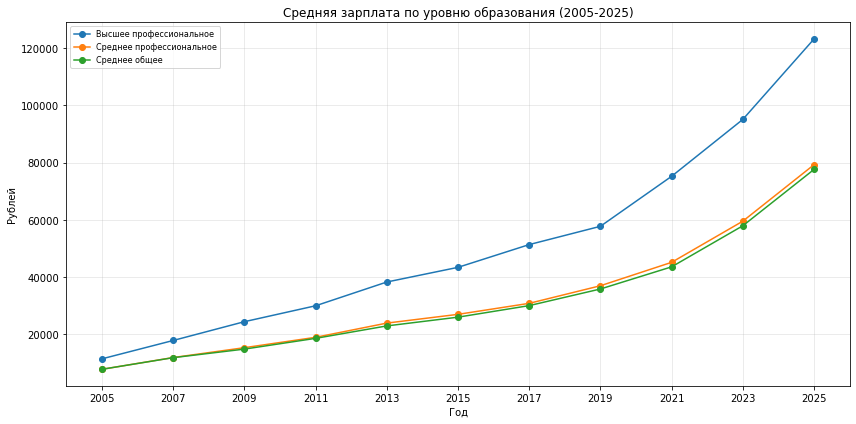

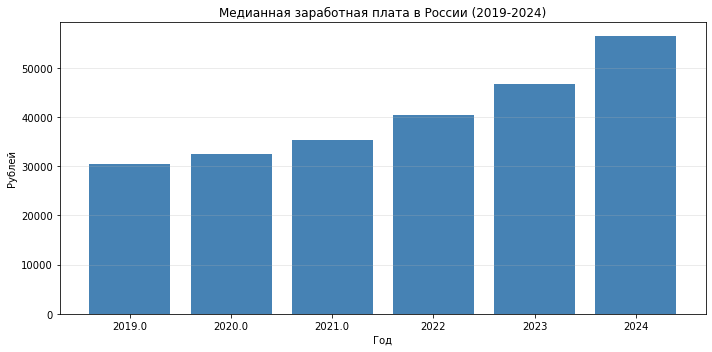

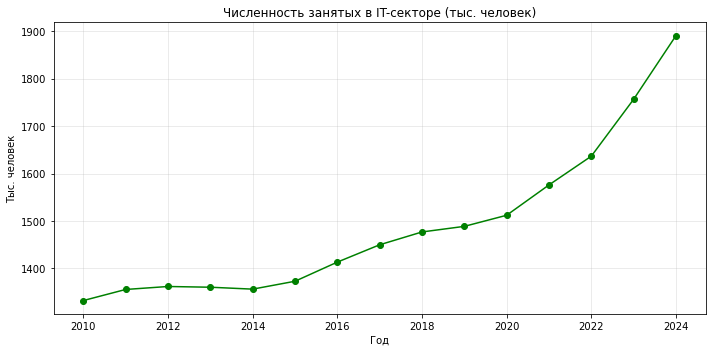

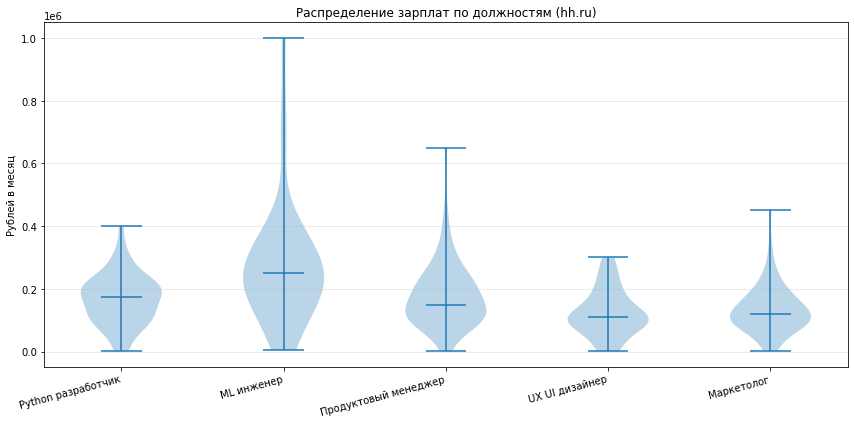

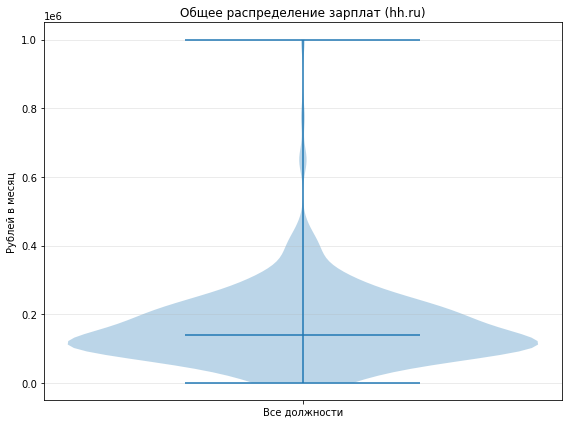

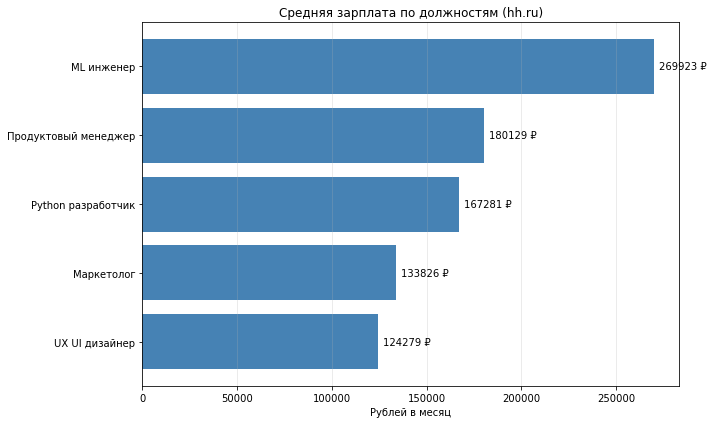

In [8]:
analyzer = DataAnalyzer(edu_clean, med_clean, it_combined, df_hh)
analyzer.plot_edu_salaries()
analyzer.plot_median()
analyzer.plot_it_employment()
analyzer.plot_hh_violin()
analyzer.plot_hh_violin_total()
analyzer.plot_hh_avg()

### Дашборд

In [ ]:
class Dashboard:
    def __init__(self, analyzer):
        self.analyzer = analyzer
        self.app = Dash(__name__)
        self.setup_layout()

    def setup_layout(self):
        hh_data = self.analyzer.hh
        edu_data = self.analyzer.edu
        med_data = self.analyzer.median
        it_data = self.analyzer.it

        edu_melted = edu_data.reset_index().melt(id_vars="категория", var_name="год", value_name="зарплата")
        fig_edu = px.line(
            edu_melted, x="год", y="зарплата", color="категория",
            title="Средняя зарплата по уровню образования (2005-2025)",
            labels={"зарплата": "Рублей", "год": "Год"}
        )

        fig_median = px.bar(
            x=med_data.index.astype(str), y=med_data.values,
            title="Медианная зарплата в России (2019-2024)",
            labels={"x": "Год", "y": "Рублей"}
        )

        fig_it = px.line(
            x=it_data.index, y=it_data.values,
            title="Численность занятых в IT-секторе (тыс. человек)",
            labels={"x": "Год", "y": "Тыс. человек"},
            markers=True
        )
        
        fig_violin_all = px.violin(
            hh_data, y="зп_средняя",
            title="Распределение зарплат по должностям (hh.ru)",
            box=True, labels={"зп_средняя": "Рублей в месяц"}
        )
        
        fig_violin = px.violin(
            hh_data, x="запрос", y="зп_средняя",
            title="Распределение зарплат по должностям (hh.ru)",
            box=True, labels={"зп_средняя": "Рублей в месяц", "запрос": "Должность"}
        )

        avg = hh_data.groupby("запрос")["зп_средняя"].mean().reset_index()
        fig_avg = px.bar(
            avg, x="зп_средняя", y="запрос", orientation="h",
            title="Средняя зарплата по должностям (hh.ru)",
            labels={"зп_средняя": "Рублей в месяц", "запрос": "Должность"}
        )

        self.app.layout = html.Div([
            html.H1("Анализ кадров — Калькулятор стоимости бизнеса",
                    style={"textAlign": "center", "fontFamily": "Arial"}),
            html.H2("Данные Росстат", style={"fontFamily": "Arial"}),
            dcc.Graph(figure=fig_edu),
            dcc.Graph(figure=fig_median),
            dcc.Graph(figure=fig_it),
            html.H2("Данные hh.ru", style={"fontFamily": "Arial"}),
            dcc.Graph(figure=fig_violin_all),
            dcc.Graph(figure=fig_violin),
            dcc.Graph(figure=fig_avg),
        ])

    def run(self):
        self.app.run(debug=False, port=8050)

dashboard = Dashboard(analyzer)
dashboard.run()

Dash is running on http://127.0.0.1:8050/

 * Serving Flask app "__main__" (lazy loading)
 * Environment: production
   Use a production WSGI server instead.
 * Debug mode: off


 * Running on http://127.0.0.1:8050/ (Press CTRL+C to quit)
